<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/homework/tf-idf/1b-manchester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [22]:

import nltk
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
!pip install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download resource NLTK yang dibutuhkan sekali saja
nltk.download('punkt')
nltk.download('punkt_tab')

import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 2. Define Document

In [23]:
document_text = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

# Text Preprocessing

In [24]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords') # Download the stopwords corpus

# Tokenisasi kalimat
sentences = sent_tokenize(document_text)

# Get English stopwords
english_stopwords = set(stopwords.words('english'))

# Pembersihan kalimat (menghapus stopword English)
cleaned_sentences = []
for s in sentences:
    words = word_tokenize(s.lower()) # Tokenize and convert to lowercase
    filtered_words = [word for word in words if word.isalnum() and word not in english_stopwords] # Filter out non-alphanumeric and stopwords
    cleaned_sentences.append(" ".join(filtered_words))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
# Display a few original and cleaned sentences
print("--- Original vs. Cleaned Sentences ---")
for i in range(min(3, len(sentences))):
    print(f"Original Sentence {i+1}: {sentences[i]}")
    print(f"Cleaned Sentence {i+1}: {cleaned_sentences[i]}\n")

print(f"Total sentences tokenized: {len(sentences)}")
print(f"Total cleaned sentences: {len(cleaned_sentences)}")

--- Original vs. Cleaned Sentences ---
Original Sentence 1: 
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Cleaned Sentence 1: manchester city makes history winning club world cup manchester city capped incredible year yet another trophy dismantling fluminense win club world cup friday

Original Sentence 2: Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
Cleaned Sentence 2: already premier league champions league fa cup super cup pep guardiola side boasts five trophies calendar year becoming first english club ever hold titles simultaneously

Original Sentence 3: The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed i

# TF-IDF

In [26]:
# Training TF-IDF pada kalimat yang sudah dibersihkan
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()


In [27]:
print(f"TF-IDF Feature Matrix")
print(tfidf_matrix)

print(f"TF-IDF Matrix Shape (sentences x unique words):")
print(tfidf_matrix.shape)

print(f"\nFeature Names: ")
print(feature_names)

if cleaned_sentences:
    first_cleaned_sentence_tfidf = tfidf_matrix[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(tfidf_matrix, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

TF-IDF Feature Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 254 stored elements and shape (20, 195)>
  Coords	Values
  (0, 103)	0.3303342590916475
  (0, 36)	0.24419783522831462
  (0, 100)	0.20823534147749018
  (0, 84)	0.20823534147749018
  (0, 190)	0.20823534147749018
  (0, 39)	0.3026045242569144
  (0, 191)	0.3660841050487077
  (0, 45)	0.3660841050487077
  (0, 30)	0.18304205252435385
  (0, 89)	0.16516712954582374
  (0, 192)	0.16516712954582374
  (0, 193)	0.18304205252435385
  (0, 11)	0.18304205252435385
  (0, 176)	0.20823534147749018
  (0, 51)	0.20823534147749018
  (0, 73)	0.18304205252435385
  (0, 189)	0.1513022621284572
  (0, 78)	0.20823534147749018
  (1, 39)	0.14791050371062428
  (1, 45)	0.357877559902148
  (1, 192)	0.16146456096485481
  (1, 8)	0.20356730834691508
  (1, 134)	0.178938779951074
  (1, 95)	0.357877559902148
  (1, 33)	0.20356730834691508
  :	:
  (17, 151)	0.20328427306142172
  (17, 26)	0.20328427306142172
  (17, 129)	0.20328427306142172
  (17, 188

# Calculate Sentence Score

In [28]:
# Variable initialization
sent_index = 0
sentence_scores = [] #

# Calculate sentence TF-IDF score
print("--- Sentence TF-IDF Scores ---")
for idx, i in enumerate(tfidf_matrix):
    sent_score = i.sum()
    sent_length = len(i.data) # Number of words with non-zero TF-IDF
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sentence_scores.append(avg_score)
    print(f"Sentence {idx+1}: TF-IDF Sum = {sent_score:.4f}, Word Count (non-zero TF-IDF) = {sent_length}, Average TF-IDF = {avg_score:.4f}")


--- Sentence TF-IDF Scores ---
Sentence 1: TF-IDF Sum = 4.0725, Word Count (non-zero TF-IDF) = 18, Average TF-IDF = 0.2263
Sentence 2: TF-IDF Sum = 4.6474, Word Count (non-zero TF-IDF) = 23, Average TF-IDF = 0.2021
Sentence 3: TF-IDF Sum = 3.7128, Word Count (non-zero TF-IDF) = 14, Average TF-IDF = 0.2652
Sentence 4: TF-IDF Sum = 2.6316, Word Count (non-zero TF-IDF) = 7, Average TF-IDF = 0.3759
Sentence 5: TF-IDF Sum = 3.7250, Word Count (non-zero TF-IDF) = 14, Average TF-IDF = 0.2661
Sentence 6: TF-IDF Sum = 2.7350, Word Count (non-zero TF-IDF) = 8, Average TF-IDF = 0.3419
Sentence 7: TF-IDF Sum = 2.8243, Word Count (non-zero TF-IDF) = 8, Average TF-IDF = 0.3530
Sentence 8: TF-IDF Sum = 2.9674, Word Count (non-zero TF-IDF) = 9, Average TF-IDF = 0.3297
Sentence 9: TF-IDF Sum = 3.4621, Word Count (non-zero TF-IDF) = 12, Average TF-IDF = 0.2885
Sentence 10: TF-IDF Sum = 3.7357, Word Count (non-zero TF-IDF) = 14, Average TF-IDF = 0.2668
Sentence 11: TF-IDF Sum = 3.9747, Word Count (non-ze

In [29]:
print("\nList of average TF-IDF scores for each sentence:")
print(sentence_scores)


List of average TF-IDF scores for each sentence:
[np.float64(0.22625120049204187), np.float64(0.2020599269859897), np.float64(0.26520155895177566), np.float64(0.37594441273397283), np.float64(0.26607326561013644), np.float64(0.34188121751768485), np.float64(0.35303861869140085), np.float64(0.3297108524194425), np.float64(0.2885105835742803), np.float64(0.26683398987072904), np.float64(0.24841611935072547), np.float64(0.33288895222983694), np.float64(0.2882548250969759), np.float64(0.3122655397011415), np.float64(0.5762424963058678), np.float64(0.23920769325933014), np.float64(0.24610206605064502), np.float64(0.19331233172379197), np.float64(0.3156161676636163), np.float64(0.3330860547454032)]


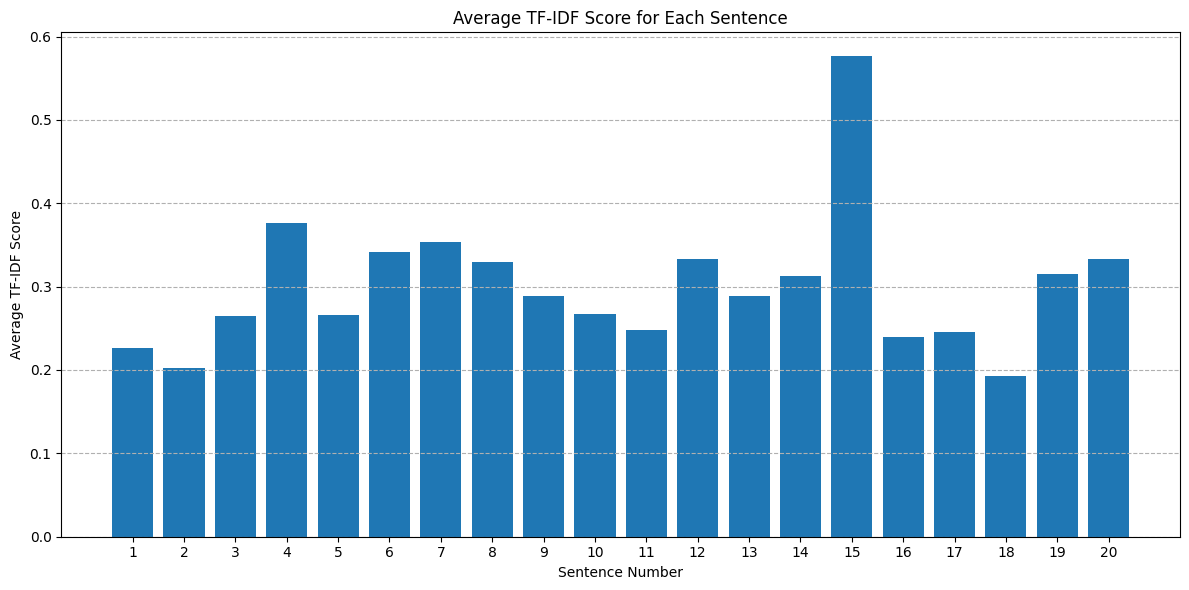

In [30]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sentence_scores) + 1), sentence_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sentence_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Define Threshold

In [33]:
# Calculate the average of all sentence scores (threshold)
threshold = sum(sentence_scores) / len(sentence_scores) if sentence_scores else 0

print("\nThreshold (Average of Sentence Scores):", threshold)

# Use the cleaned_sentences from the previous step
all_cleaned_sentences = cleaned_sentences

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "world" in each sentence using the already cleaned sentences
tfidf_scores = {}
for i in range(len(sentences)): # Iterate through index
    cleaned_sentence = all_cleaned_sentences[i] # Get the pre-cleaned sentence
    tf = calculate_tf("world", cleaned_sentence)
    idf = calculate_idf("world", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "world" in each sentence
print("TF-IDF Score for 'world' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "world" across all cleaned sentences
overall_idf_investasi = calculate_idf("world", all_cleaned_sentences)
print(f"\nOverall IDF for 'world': {overall_idf_investasi:.4f}")


# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
try:
    # Reusing existing tfidf_matrix and feature_names computed in cell Cc2siGzfQKiP
    # These were already calculated on 'cleaned_sentences'.
    investasi_index = list(feature_names).index("world")
    print("\nTF-IDF Score for 'world' using TfidfVectorizer (from cleaned_sentences):")
    for i in range(len(cleaned_sentences)): # Iterate through cleaned sentences
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'world' not found in the vocabulary after stop word removal by TfidfVectorizer.")



Threshold (Average of Sentence Scores): 0.3000448936487395
TF-IDF Score for 'world' in each cleaned sentence:
Sentence 1: 0.2002
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.3289
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000

Overall IDF for 'world': 2.3026

TF-IDF Score for 'world' using TfidfVectorizer (from cleaned_sentences):
Sentence 1: 0.3661
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.3502
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.0000
Sentence 20: 0.0000


# Get Sentences

In [34]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, score in enumerate(sentence_scores):
    if score >= threshold:
        final_summ = final_summ + " " + sentences[index]
        print(f"- {sentences[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())


**Summary Sentences (above or equal to the threshold):**
- “We’ve shown over the past 12 months we are the best team in the world.
- “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
- I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
- I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
- “As a manager it is what I am most proud of; that we are always there.
- The champion heads back to England where it faces a tough title defence in the Premier League.
- It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.

**Final Summary:**
“We’ve shown over the past 12 months we a

# Summarization Result

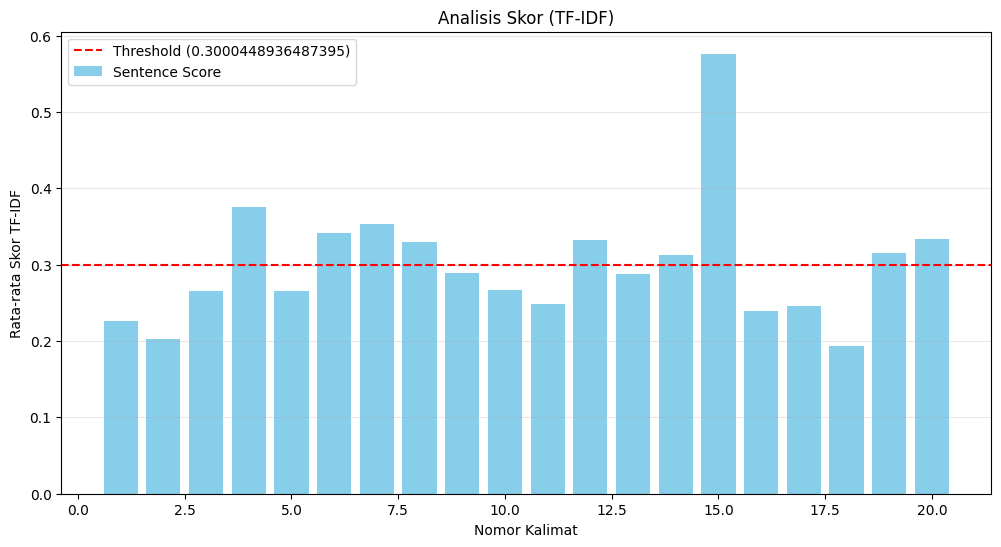


HASIL RINGKASAN AKHIR
“We’ve shown over the past 12 months we are the best team in the world. “To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead. Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range. City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year. “As a manager it is what I am most proud of; that we are always there. The champion heads back to England where it faces a tough title defence in the Premier League. It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.


In [36]:
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sentence_scores) + 1), sentence_scores, color='skyblue', label='Sentence Score')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel("Nomor Kalimat")
plt.ylabel("Rata-rata Skor TF-IDF")
plt.title("Analisis Skor (TF-IDF)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 8. Final Output
# ==========================================
print("\n" + "="*30)
print("HASIL RINGKASAN AKHIR")
print("="*30)
print(final_summ.strip())